# EDA

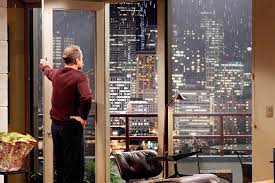

My client:

Nicole Johnson 

Buyer 
   
Lively, central neighborhood, middle price range, right timing (within a year)

✅ STEP 1 — Understanding the Data


In [28]:
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from matplotlib.ticker import PercentFormatter
plt.rcParams.update({ "figure.figsize" : (8, 5),"axes.facecolor" : "white", "axes.edgecolor":  "black"})
plt.rcParams["figure.facecolor"]= "w"
pd.plotting.register_matplotlib_converters()
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [29]:
df_import = pd.read_csv('data/eda.csv')

In [30]:
type(df_import['date'][0])  #is the 'date' a string?

str

In [31]:
df_import['date'] = pd.to_datetime(df_import['date'], format='%Y-%m-%d') #..it is, so let us change it
type(df_import['date'][0])          #check the outcome

pandas._libs.tslibs.timestamps.Timestamp

In [32]:
df_import.describe()

,date,price,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,21597,21597.000,21597.000,21597.000,21597.000,21597.000,21597.000,21597.000,19206.000,21534.000,...,21597.000,21597.000,21145.000,21597.000,17749.000,21597.000,21597.000,21597.000,21597.000,21597.000
mean,2014-10-29 04:20:38.171968512,540296.574,4580474287.771,3.373,2.116,2080.322,15099.409,1.494,0.008,0.234,...,7.658,1788.597,291.857,1971.000,836.651,98077.952,47.560,-122.214,1986.620,12758.284
min,2014-05-02 00:00:00,78000.000,1000102.000,1.000,0.500,370.000,520.000,1.000,0.000,0.000,...,3.000,370.000,0.000,1900.000,0.000,98001.000,47.156,-122.519,399.000,651.000
25%,2014-07-22 00:00:00,322000.000,2123049175.000,3.000,1.750,1430.000,5040.000,1.000,0.000,0.000,...,7.000,1190.000,0.000,1951.000,0.000,98033.000,47.471,-122.328,1490.000,5100.000
50%,2014-10-16 00:00:00,450000.000,3904930410.000,3.000,2.250,1910.000,7618.000,1.500,0.000,0.000,...,7.000,1560.000,0.000,1975.000,0.000,98065.000,47.572,-122.231,1840.000,7620.000
75%,2015-02-17 00:00:00,645000.000,7308900490.000,4.000,2.500,2550.000,10685.000,2.000,0.000,0.000,...,8.000,2210.000,560.000,1997.000,0.000,98118.000,47.678,-122.125,2360.000,10083.000
max,2015-05-27 00:00:00,7700000.000,9900000190.000,33.000,8.000,13540.000,1651359.000,3.500,1.000,4.000,...,13.000,9410.000,4820.000,2015.000,20150.000,98199.000,47.778,-121.315,6210.000,871200.000
std,NaN,367368.140,2876735715.748,0.926,0.769,918.106,41412.637,0.540,0.087,0.766,...,1.173,827.760,442.491,29.375,4000.111,53.513,0.139,0.141,685.230,27274.442


In [33]:
df_import.shape

(21597, 21)

In [34]:
df_import.head(5)

,date,price,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,2014-10-13,221900.000,7129300520,3.000,1.000,1180.000,5650.000,1.000,NaN,0.000,...,7,1180.000,0.000,1955,0.000,98178,47.511,-122.257,1340.000,5650.000
1,2014-12-09,538000.000,6414100192,3.000,2.250,2570.000,7242.000,2.000,0.000,0.000,...,7,2170.000,400.000,1951,19910.000,98125,47.721,-122.319,1690.000,7639.000
2,2015-02-25,180000.000,5631500400,2.000,1.000,770.000,10000.000,1.000,0.000,0.000,...,6,770.000,0.000,1933,NaN,98028,47.738,-122.233,2720.000,8062.000
3,2014-12-09,604000.000,2487200875,4.000,3.000,1960.000,5000.000,1.000,0.000,0.000,...,7,1050.000,910.000,1965,0.000,98136,47.521,-122.393,1360.000,5000.000
4,2015-02-18,510000.000,1954400510,3.000,2.000,1680.000,8080.000,1.000,0.000,0.000,...,8,1680.000,0.000,1987,0.000,98074,47.617,-122.045,1800.000,7503.000


In [35]:
import missingno as msno
df_import.isna().sum().sort_values(ascending=False)

yr_renovated     3848
waterfront       2391
sqft_basement     452
view               63
date                0
bathrooms           0
bedrooms            0
id                  0
price               0
floors              0
condition           0
sqft_lot            0
sqft_living         0
sqft_above          0
grade               0
yr_built            0
zipcode             0
lat                 0
long                0
sqft_living15       0
sqft_lot15          0
dtype: int64

<Axes: >

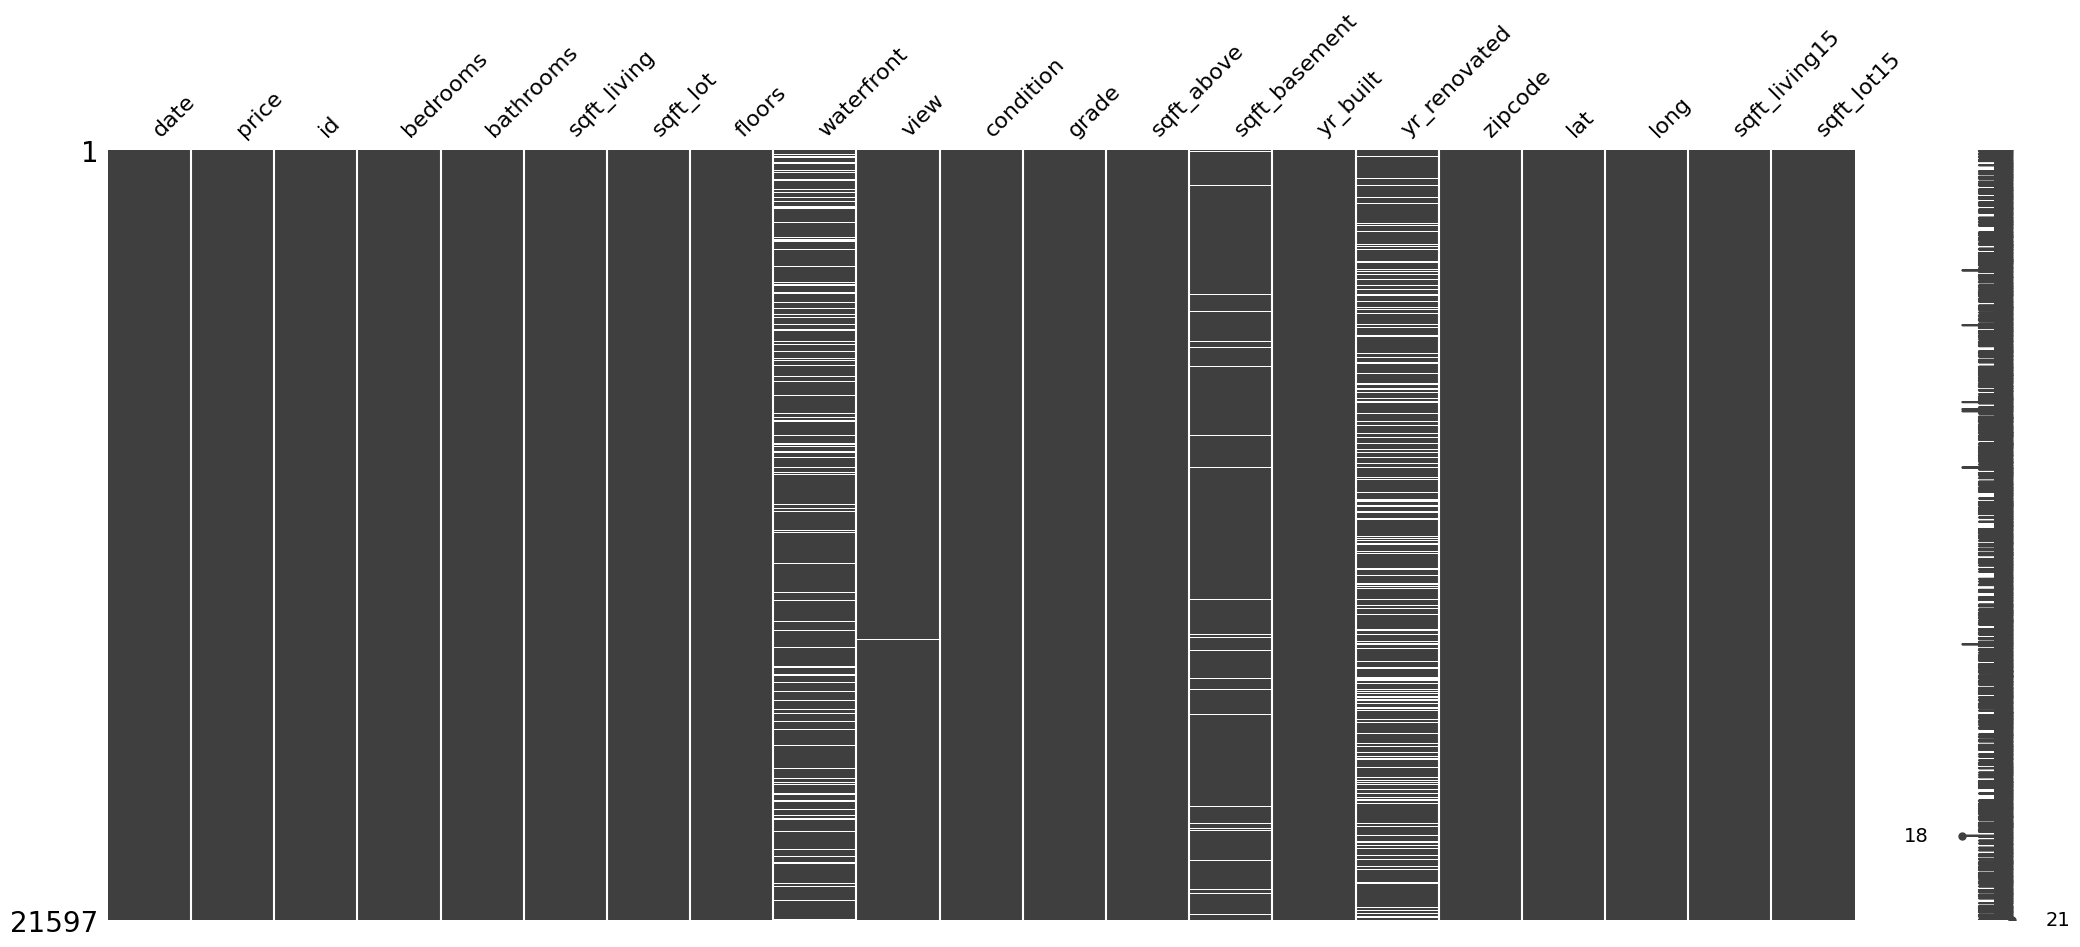

In [36]:
msno.matrix(df_import)

In [37]:
#Grouping/marking column names into numeric continuous and categorical variables so to know how to analyze every group
continuous_features = [
    "price", "sqft_living", "sqft_lot", "sqft_above", "sqft_basement",
    "sqft_living15", "sqft_lot15", "lat", "long",
    "bathrooms", "floors"
]
categorical_features = [
    "bedrooms", "waterfront", "view", "condition", "grade",
    "zipcode", "yr_built", "yr_renovated"
]
#to help with plotting, scaling, and interpretation:

In [38]:
print("Continuous features:", continuous_features)          #numbers with a wide range
#Continuous Features: Show histograms, Calculate correlations, Identify skew/outliers

Continuous features: ['price', 'sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15', 'lat', 'long', 'bathrooms', 'floors']


In [39]:
print("Categorical features:", categorical_features)        #categorical (some ordinal) roups, categories, or ordered labels
#Categorical Features: Show countplots, Compare price means/medians, Identify most common categories

Categorical features: ['bedrooms', 'waterfront', 'view', 'condition', 'grade', 'zipcode', 'yr_built', 'yr_renovated']


In [40]:
df_import.duplicated().value_counts()   #checking duplicates
#no duplicates since the return is False is every row

False    21597
Name: count, dtype: int64

In [41]:
df_import["id"].nunique()       #Check unique values for key identifiers, some houses were apparently sold twice

21420

In [42]:
df_import[["bedrooms","bathrooms","sqft_living","sqft_lot"]].describe()
#how many of us have ever heard of a house with 33 bedrooms? Definitely not for Nicole :)
#Outliers: 33 bedrooms as a max, 1,6 mill sqft lot (crazy!), lots of bathrooms are probably incorrect data

,bedrooms,bathrooms,sqft_living,sqft_lot
count,21597.000,21597.000,21597.000,21597.000
mean,3.373,2.116,2080.322,15099.409
std,0.926,0.769,918.106,41412.637
min,1.000,0.500,370.000,520.000
25%,3.000,1.750,1430.000,5040.000
50%,3.000,2.250,1910.000,7618.000
75%,4.000,2.500,2550.000,10685.000
max,33.000,8.000,13540.000,1651359.000


In [43]:
df_import['waterfront'].unique()            #as we see, all floats and float NaN is not the same as pandas NA:
#incorrect representation of integers. Int64 is better since it  represents real integers and proper missing values in pandas NA...

array([nan,  0.,  1.])

In [44]:
df_import['waterfront'] = df_import['waterfront'].astype('Int64')       #....so transform as int64

type(df_import['waterfront'].iloc[0])

pandas._libs.missing.NAType

In [45]:
df_import[["lat", "long"]].describe()
#lat → latitude (north–south position)
#long → longitude (east–west position)

,lat,long
count,21597.000,21597.000
mean,47.560,-122.214
std,0.139,0.141
min,47.156,-122.519
25%,47.471,-122.328
50%,47.572,-122.231
75%,47.678,-122.125
max,47.778,-121.315


In [46]:
df_import[["price", "lat", "long"]].corr()
#As latitude increases (north), price tends to increase.
#This confirms that northern / central areas tend to be more expensive.

,price,lat,long
price,1.000,0.307,0.022
lat,0.307,1.000,-0.135
long,0.022,-0.135,1.000


 STEP 2 — Research Questions & Hypothesis Generation

What is important for me for creating the RQs and Hs?
1) Variables existing in the dataset:   

location features (lat, long, zipcode)  →   ....does location matter?   

renovation info (yr_renovated)      →   ....does renovation matter?


2) Logical assumptions (pre-data assumptions)

Central areas are more expensive → 

Renovated homes cost more → 


2) Indicatior from my dataset

A) Geography

The dataset includes lat/long and zipcode, which always show spatial price differences in real estate.
→ "Does location matter?" 

B) Renovation

Column yr_renovated varies from 0 (never renovated) to modern years.
→ "Does renovation matter?"


In [47]:
research_questions = [
    "RQ1: Will Nicole find an affordable property in a central neighborhood?",    
    "RQ2: How does location affect house prices?",               #geographical - zipcode, lat, lon
    "RQ4: Are renovated homes more expensive than non-renovated homes?"
]

hypotheses = [
    "H1: Nicole won't be able to find an affordable and mid-priced house in a central neighborhood",
    "H3: Homes in central/northern coordinates have higher prices.",
    "H3: Recently renovated homes are more expensive than non-renovated ones."
]

print("Research Questions:")
for r in research_questions:
    print("-", r)

print("\nHypotheses:")
for h in hypotheses:
    print("-", h)

Research Questions:
- RQ1: Will Nicole find an affordable property in a central neighborhood?
- RQ2: How does location affect house prices?
- RQ4: Are renovated homes more expensive than non-renovated homes?

Hypotheses:
- H1: Nicole won't be able to find an affordable and mid-priced house in a central neighborhood
- H3: Homes in central/northern coordinates have higher prices.
- H3: Recently renovated homes are more expensive than non-renovated ones.


In [48]:
df_import['price_log'] = np.log(df_import['price'])         #price is strongly right-skewed.
df_import['sqft_lot_log'] = np.log(df_import['sqft_lot'] + 1)    #adding +1 prevents log(0) error
#Lot size is the most skewed variable, so this will help the most.
df_import['sqft_living_log'] = np.log(df_import['sqft_living'])   #sqft_living is skewed, and log makes relationships clearer.
df_import['sqft_living15_log'] = np.log(df_import['sqft_living15']) #neighborhood average living space is also skewed.
df_import['sqft_above_log'] = np.log(df_import['sqft_above'])
df_import['sqft_basement_log'] = np.log(df_import['sqft_basement'] + 1)
df_import["sqft_lot15_log"] = np.log(df_import["sqft_lot15"] + 1)

In [49]:
log_features = [
    "price_log", 
    "sqft_lot_log", 
    "sqft_living_log", 
    "sqft_living15_log",
    'sqft_above_log',
    'sqft_basement_log',
    'sqft_lot15_log'
]


 STEP 3 — Exploring the Data

What do the distributions look like? Are variables skewed?
Are there outliers?
Are categories balanced or imbalanced?
Can I spot any suspicious values?

3.1 Histograms of Continuous Features

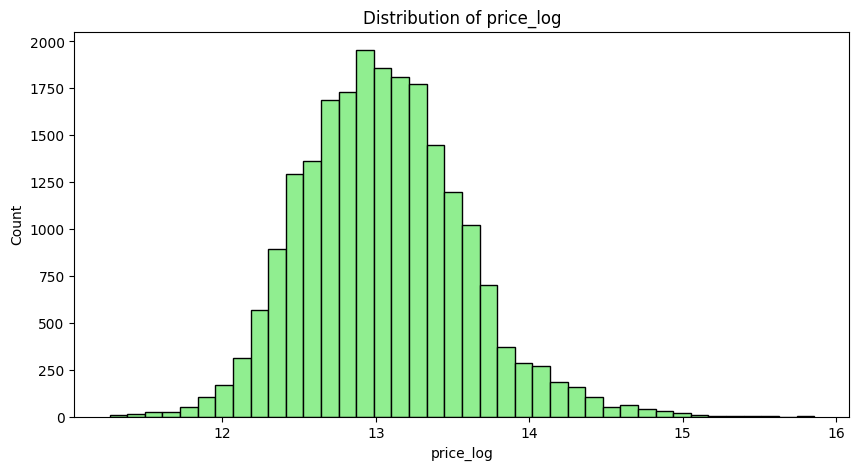

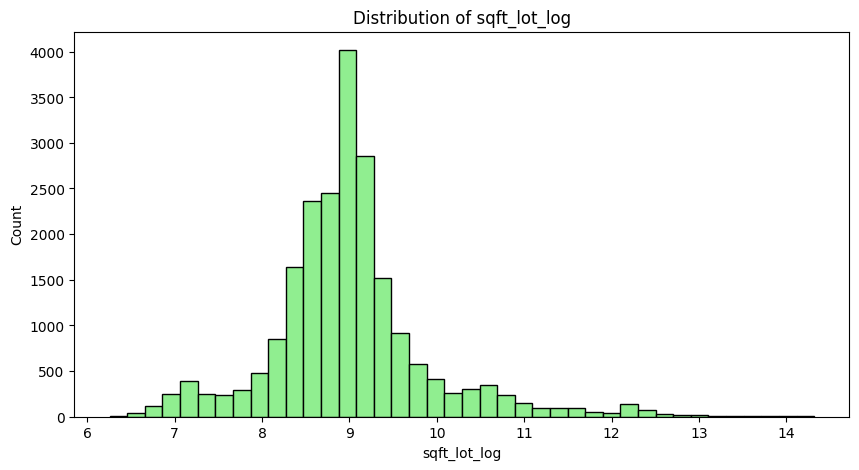

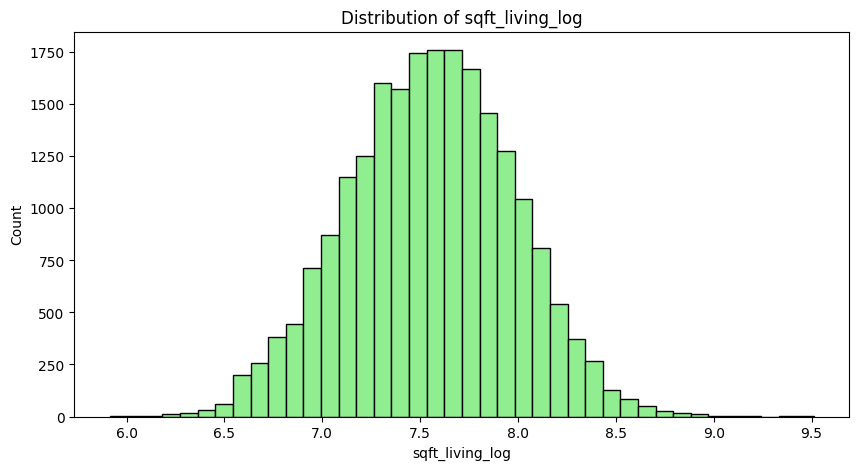

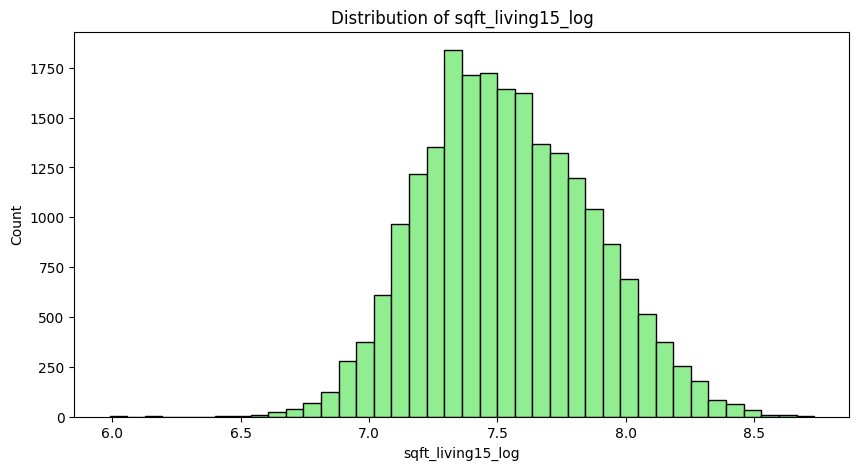

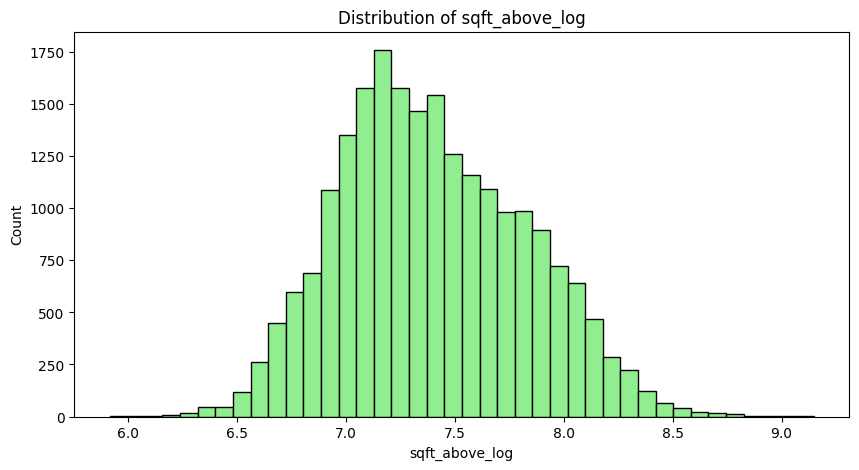

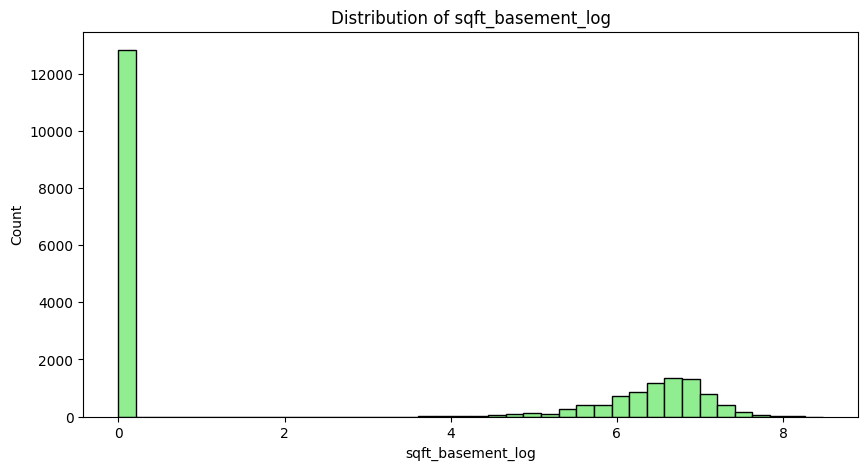

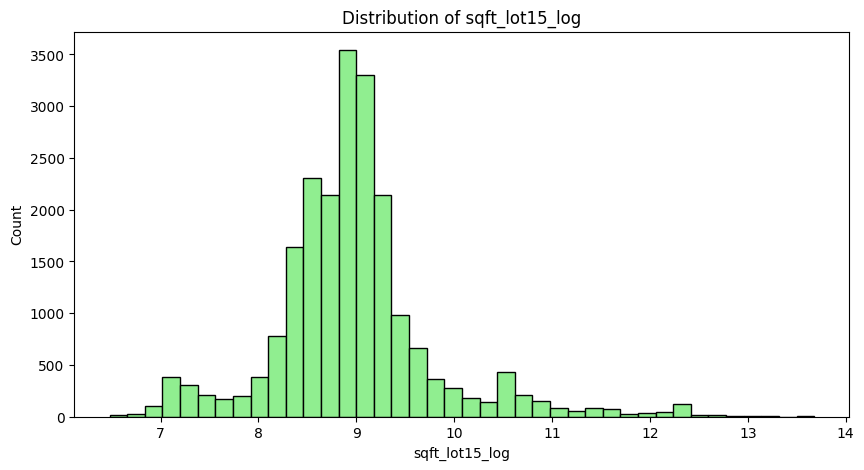

In [50]:
#optional
for col in log_features:
    plt.figure(figsize=(10,5))
    plt.hist(df_import[col], bins=40, color='lightgreen', edgecolor='black')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.grid(False)
    plt.show()

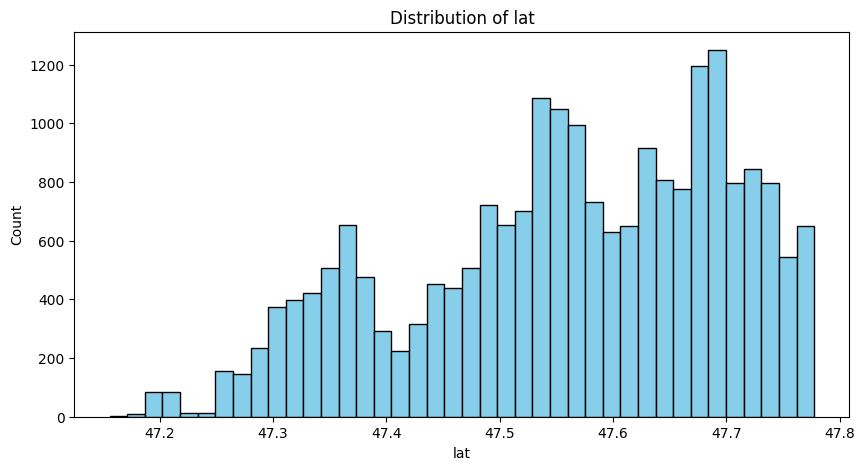

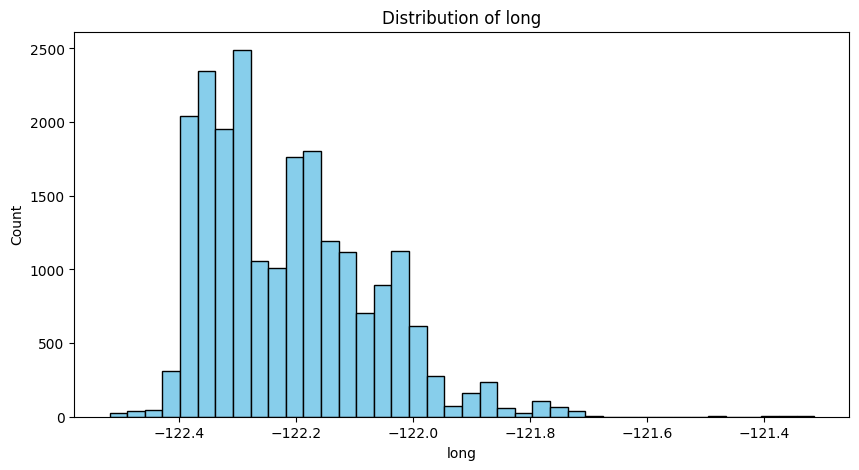

In [51]:
#optional
continuous_hist_features = ["lat", "long"]
for col in continuous_hist_features:
    plt.figure(figsize=(10,5))
    plt.hist(df_import[col], bins=40, color='skyblue', edgecolor='black')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.grid(False)
    plt.show()

3.2 Countplots / Value Counts for Categorical Features

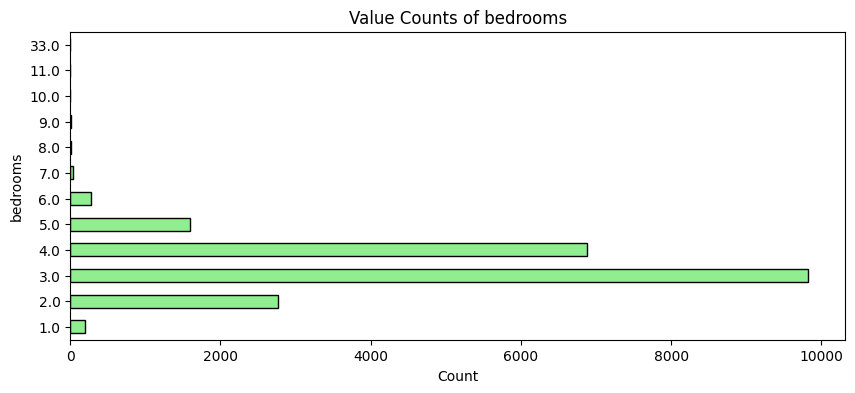

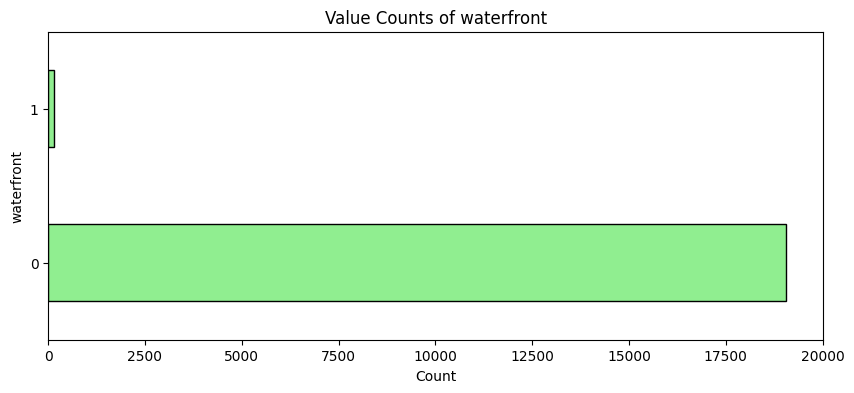

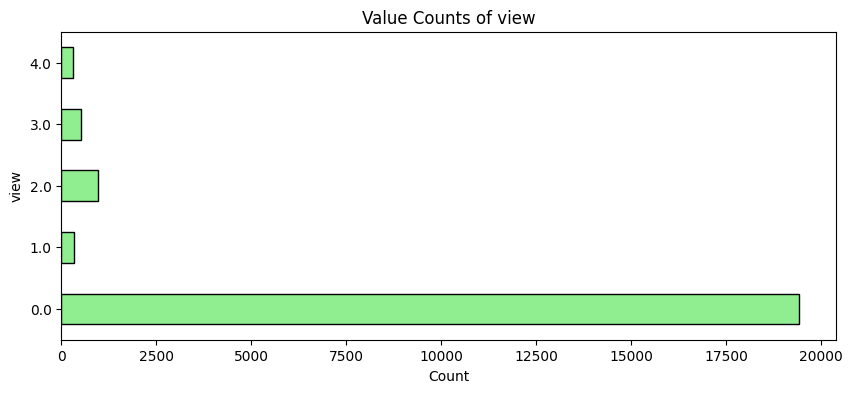

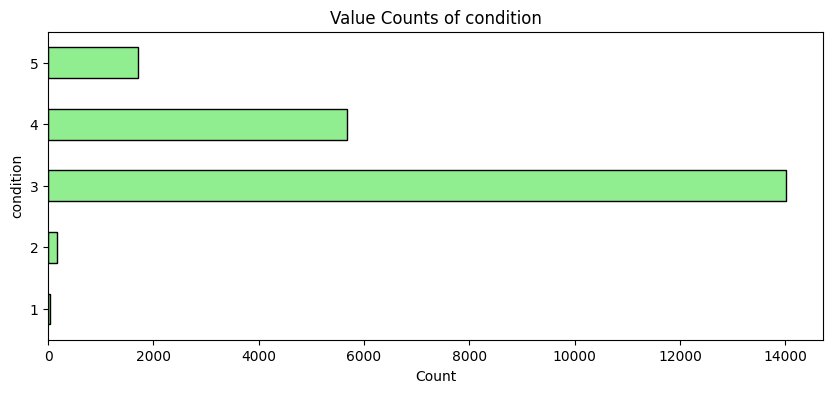

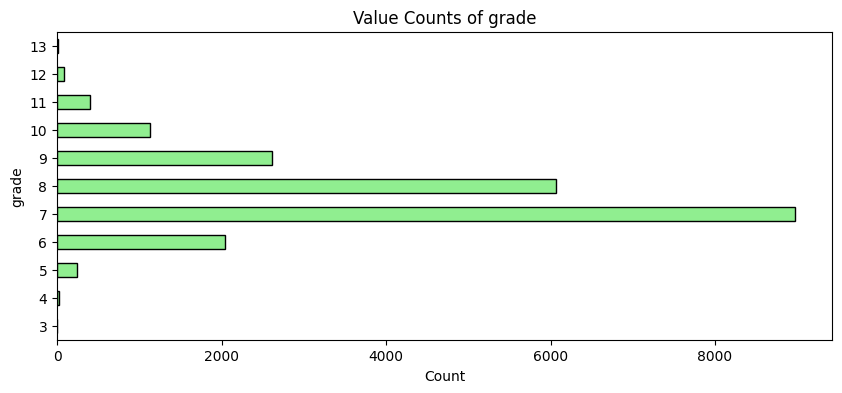

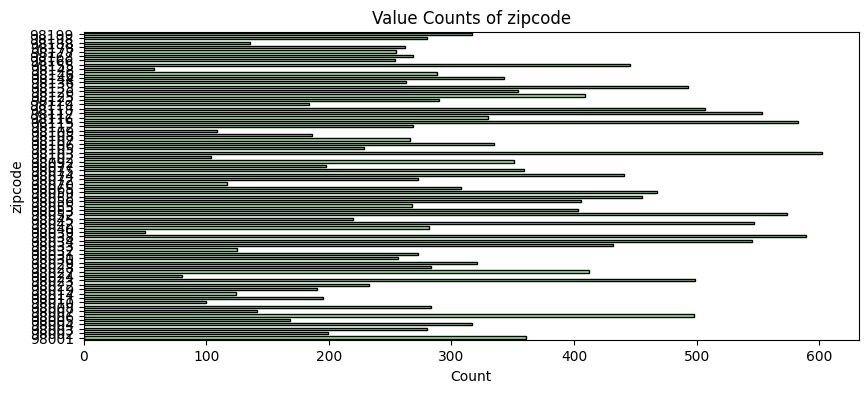

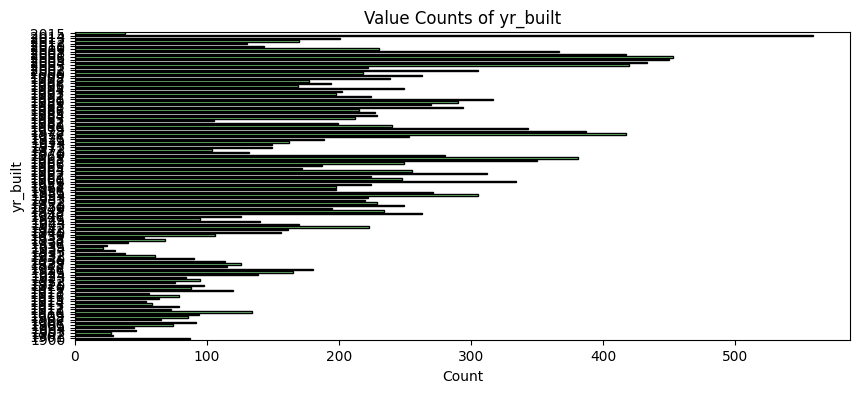

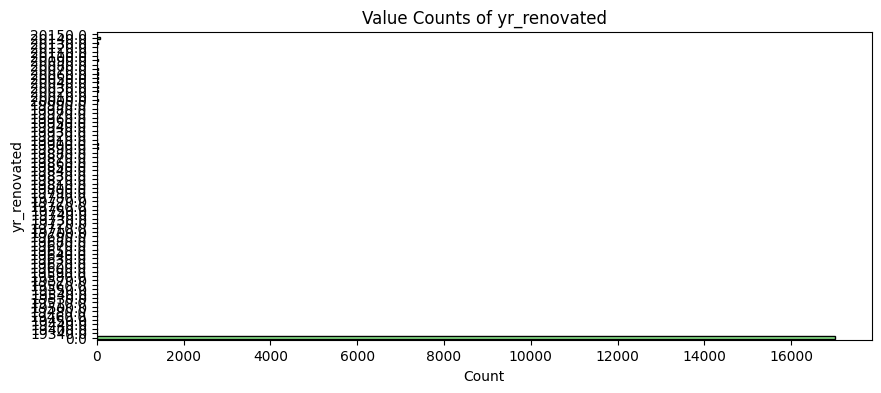

In [52]:
#optional
for col in categorical_features:
    plt.figure(figsize=(10,4))
    df_import[col].value_counts().sort_index().plot(
        kind="barh", color='lightgreen', edgecolor="black"
    )
    plt.title(f"Value Counts of {col}")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.show()

<Axes: ylabel='zipcode'>

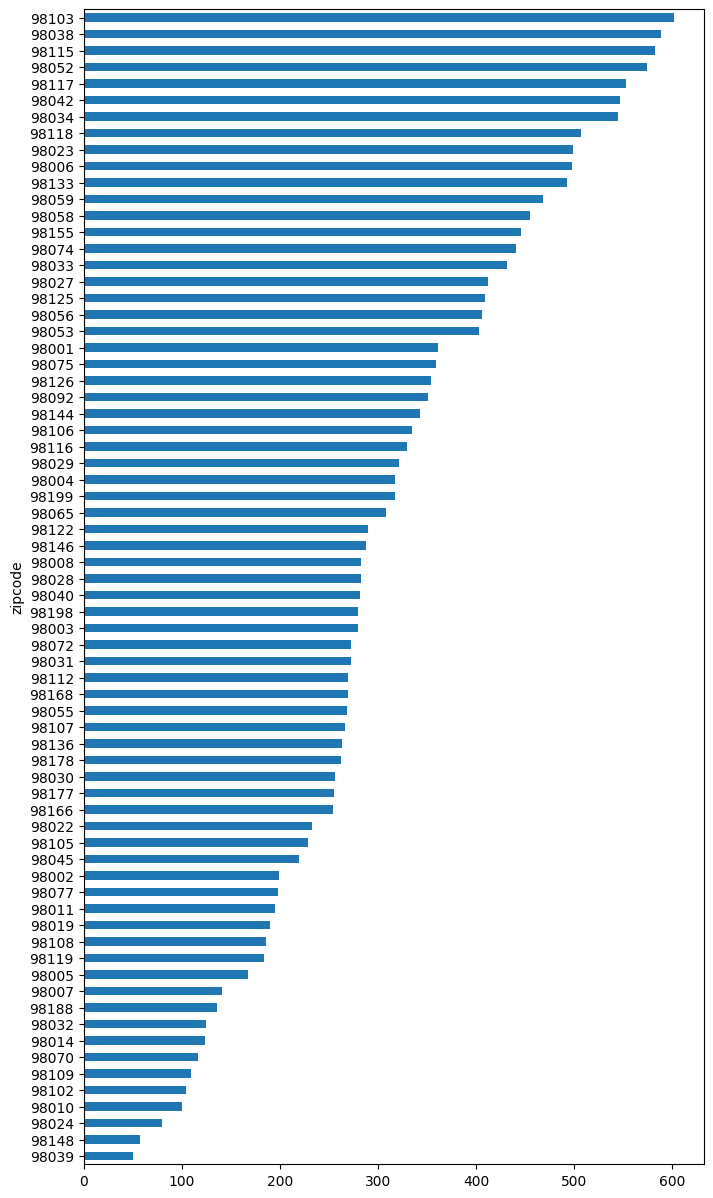

In [53]:
df_import["zipcode"].value_counts().sort_values().plot(kind='barh', figsize=(8,15))
#optionally refined zipcode

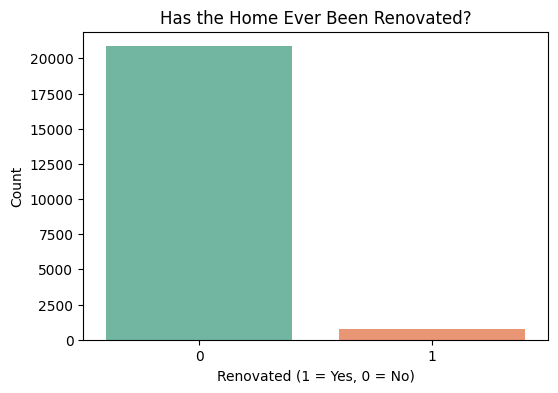

In [54]:
#semi-optional
df_import["is_renovated"] = df_import["yr_renovated"].apply(lambda x: 1 if x > 0 else 0)
plt.figure(figsize=(6,4))
sns.countplot(x="is_renovated", data=df_import, palette="Set2")
plt.title("Has the Home Ever Been Renovated?")
plt.xlabel("Renovated (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()

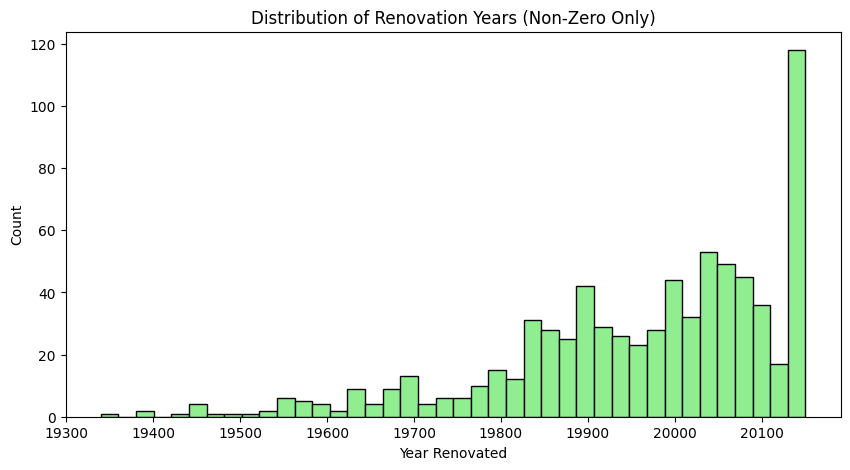

In [55]:
#renovation
renov = df_import[df_import["yr_renovated"] > 0]
plt.figure(figsize=(10,5))
plt.hist(renov["yr_renovated"], bins=40, color="lightgreen", edgecolor="black")
plt.title("Distribution of Renovation Years (Non-Zero Only)")
plt.xlabel("Year Renovated")
plt.ylabel("Count")
plt.show()

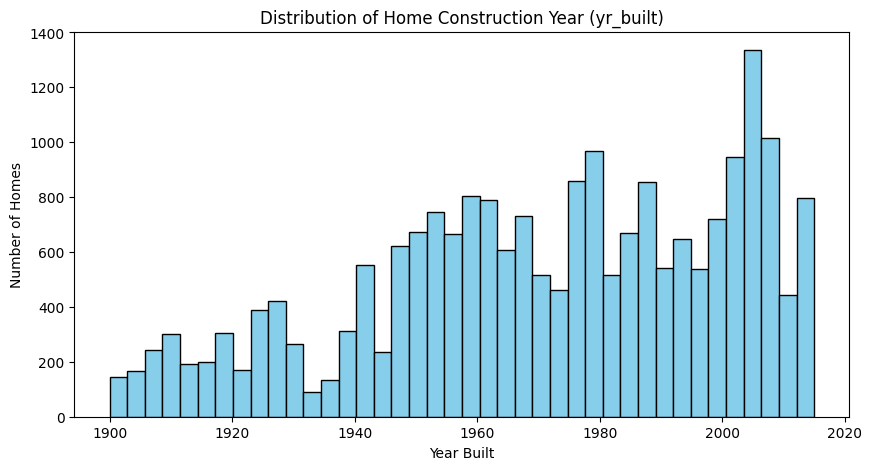

In [56]:
#optional
plt.figure(figsize=(10,5))
plt.hist(df_import["yr_built"], bins=40, color='skyblue', edgecolor='black')
plt.title("Distribution of Home Construction Year (yr_built)")
plt.xlabel("Year Built")
plt.ylabel("Number of Homes")
plt.show()

In [57]:
#skewness
df_import[[
    "price", "sqft_living", "sqft_lot", "sqft_above", "sqft_basement",
    "sqft_living15", "sqft_lot15", "bathrooms", "floors"
]].skew()

price            4.023
sqft_living      1.473
sqft_lot        13.073
sqft_above       1.447
sqft_basement    1.574
sqft_living15    1.107
sqft_lot15       9.524
bathrooms        0.520
floors           0.614
dtype: float64

In [58]:
#skewness log
df_import[[
    "price_log", "sqft_living_log", "sqft_lot_log", "sqft_above_log",
    "sqft_basement_log", "sqft_living15_log", "sqft_lot15_log"
]].skew()

price_log            0.431
sqft_living_log     -0.027
sqft_lot_log         0.963
sqft_above_log       0.260
sqft_basement_log    0.482
sqft_living15_log    0.206
sqft_lot15_log       0.967
dtype: float64

3.4 First Look for Outliers

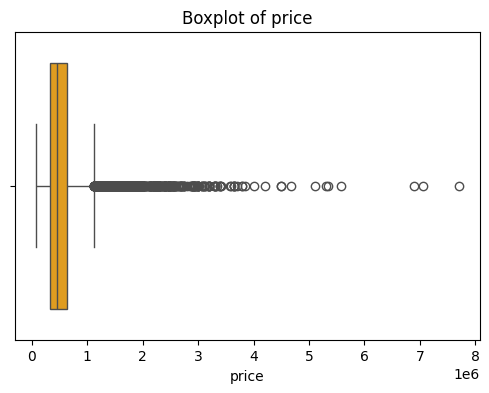

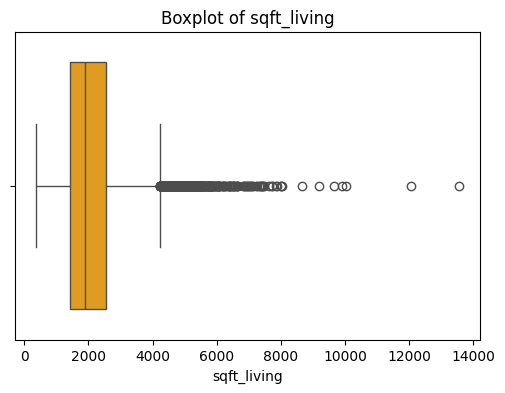

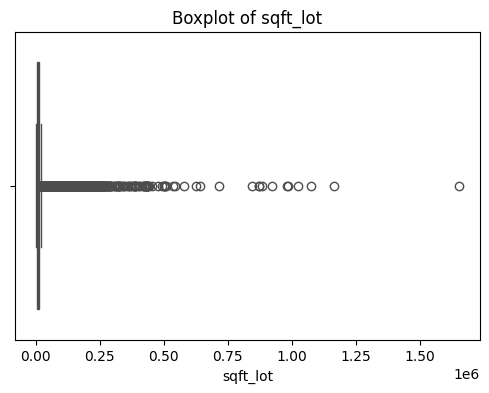

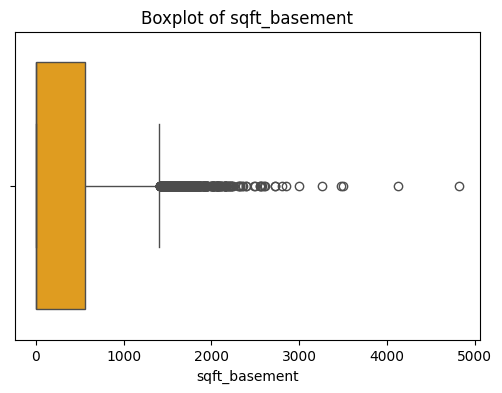

In [59]:
#semi-optional
for col in ["price", "sqft_living", "sqft_lot", "sqft_basement"]:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_import[col], color='orange')
    plt.title(f"Boxplot of {col}")
    plt.show()
    #Quick visual detection using boxplots

In [60]:
df_import[df_import["bedrooms"] > 10]
#Check specific suspicious values - Bedrooms (famous outlier in this dataset)

,date,price,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_living15,sqft_lot15,price_log,sqft_lot_log,sqft_living_log,sqft_living15_log,sqft_above_log,sqft_basement_log,sqft_lot15_log,is_renovated
8748,2014-08-21,520000.000,1773100755,11.000,3.000,3000.000,4960.000,2.000,0,0.000,...,1420.000,4960.000,13.162,8.509,8.006,7.258,7.783,6.399,8.509,1
15856,2014-06-25,640000.000,2402100895,33.000,1.750,1620.000,6000.000,1.000,0,0.000,...,1330.000,4700.000,13.369,8.700,7.390,7.193,6.947,6.365,8.456,0


In [61]:
df_import[df_import["sqft_lot"] > 200000][["sqft_lot", "price", "zipcode"]]
#filtering all houses with lots bigger that 200,000 square feet

,sqft_lot,price,zipcode
145,315374.000,921500.000,98077
238,221284.000,800000.000,98077
380,209959.000,270000.000,98011
443,219978.000,350000.000,98038
527,230652.000,1600000.000,98024
...,...,...,...
20904,215186.000,1830000.000,98029
20958,275033.000,950000.000,98045
21309,384634.000,659000.000,98019
21328,279968.000,1490000.000,98045



 STEP 4 — Cleaning the Data

4.1 Fix incorrect renovation years (very important for this dataset!)

In [62]:
# Show renovation years above a realistic limit
print(df_import[df_import["yr_renovated"] > 2024]["yr_renovated"].unique())
#Are there any renovation years in the dataset that are in the future (after 2024)? - logical question

[19910. 20020. 20100. 19920. 20130. 19940. 19780. 20050. 20030. 19840.
 19540. 20140. 20110. 19830. 19450. 19900. 19880. 19770. 19810. 19950.
 20000. 19990. 19980. 19700. 19890. 20040. 19860. 20070. 19870. 20060.
 19850. 20010. 19800. 19710. 19790. 19970. 19500. 19690. 19480. 20090.
 20150. 19740. 20080. 19680. 20120. 19630. 19510. 19620. 19530. 19930.
 19960. 19550. 19820. 19560. 19400. 19760. 19460. 19750. 19640. 19730.
 19570. 19590. 19600. 19670. 19650. 19340. 19720. 19440. 19580.]


In [63]:
df_import["yr_renovated"] = df_import["yr_renovated"].fillna(0).astype(int)
#It ensures: renovation years are integers, missing values become 0 (meaning “never renovated”)

4.2 Handling Missing Values

In [64]:
# Missing basement sizes treated as 0 = no basement
df_import["sqft_basement"] = df_import["sqft_basement"].fillna(0)

# Missing waterfront means no waterfront
df_import["waterfront"] = df_import["waterfront"].fillna(0)

# Missing view treated as 0 = no notable view
df_import["view"] = df_import["view"].fillna(0)

# Missing renovation = no renovation
df_import["yr_renovated"] = df_import["yr_renovated"].fillna(0).astype(int)
#For this dataset, missing values almost always mean “none”.

4.3 Outlier Removal (Important step)

In [65]:
df_import = df_import[df_import["bedrooms"] <= 10]
#A 33-bedroom house with just 1.75 bathrooms and 1,620 sqft is impossible = data error

In [66]:
df_import = df_import[df_import["sqft_lot"] < 200000]
#Lots over 200,000 sqft (4.5 acres) are not typical residential homes.

In [67]:
df_import = df_import[df_import["sqft_living"] < 12000]
#These are luxury mansions — they are not relevant for Nicole.

In [68]:
#optinal
df_import["decade_built"] = (df_import["yr_built"] // 10) * 10
#: Binning Year Built
#yr_built // 10 → integer division (1957 → 195)
#195 * 10 → 1950 will be the decade of construction

In [69]:
#Check how much data we removed
print("Remaining rows:", df_import.shape[0])

Remaining rows: 21336


 STEP 5 — Relationships in the Data

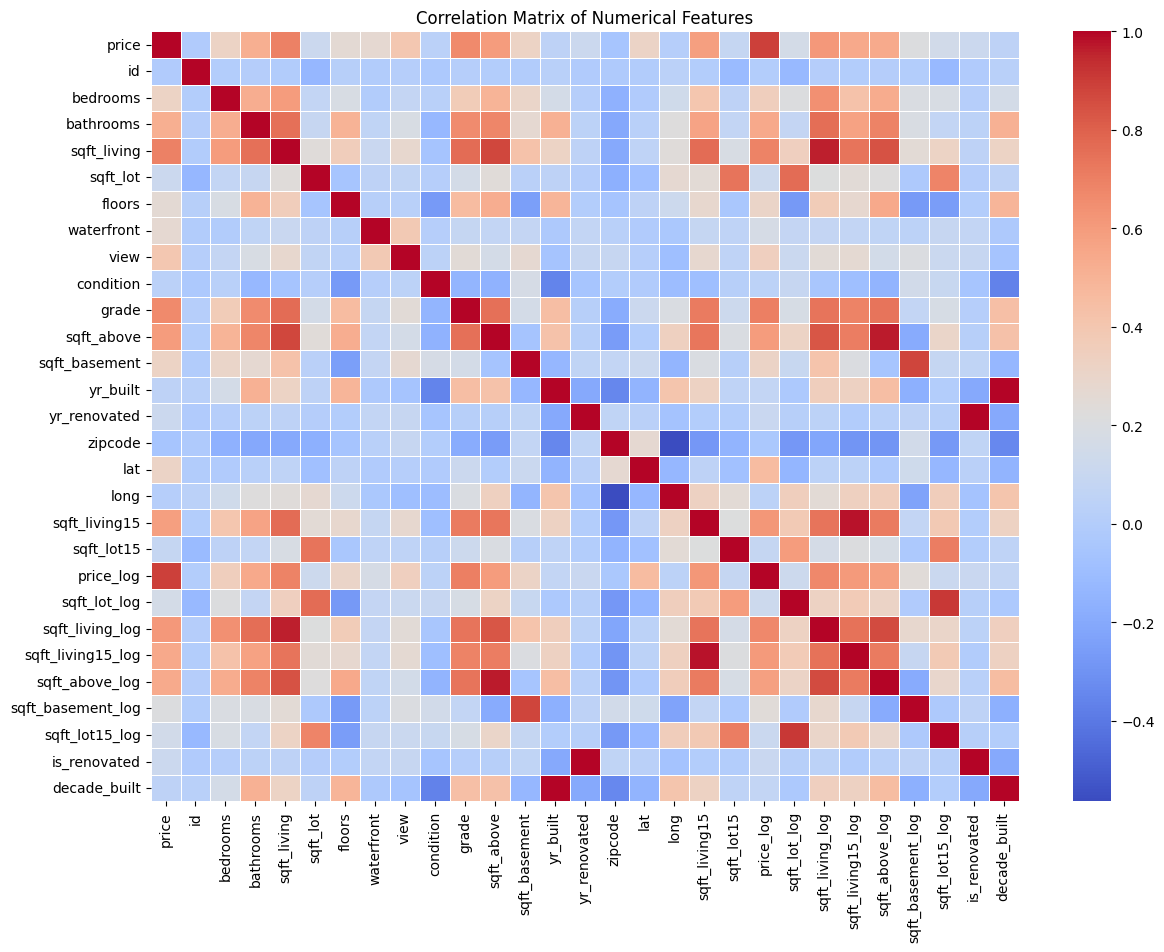

In [70]:
#Correlation Matrix (with heatmap) - optional
plt.figure(figsize=(14,10))
corr_matrix = df_import.corr(numeric_only=True)

sns.heatmap(corr_matrix,
            cmap='coolwarm',
            annot=False,
            linewidths=0.5)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [71]:
#Correlation of Each Feature with Price  - optional
corr_with_price = corr_matrix["price"].sort_values(ascending=False)
corr_with_price
#sqft_living → Bigger living area = higher price
#grade → Higher construction quality = higher price
#sqft_above → More above-ground space = higher price
#bathrooms → More bathrooms = higher price
#sqft_living15 → Homes in higher-value neighborhoods = higher price
#These are the key predictive features.
#Location variables
#lat (positive) → Homes farther north are more expensive (Seattle)
#long (negative) → Homes slightly farther east are more expensive (Bellevue)
#TO BE MENTIONED IN INSIGHTS FOR NICOLE
#This confirms lot size does not strongly affect price in King County.


price                1.000
price_log            0.895
sqft_living          0.699
grade                0.667
sqft_living_log      0.611
sqft_above           0.601
sqft_living15        0.589
sqft_living15_log    0.547
sqft_above_log       0.540
bathrooms            0.520
view                 0.396
sqft_basement        0.318
bedrooms             0.316
lat                  0.313
waterfront           0.269
floors               0.255
sqft_basement_log    0.209
sqft_lot_log         0.158
sqft_lot15_log       0.146
sqft_lot             0.118
yr_renovated         0.117
is_renovated         0.117
sqft_lot15           0.085
decade_built         0.052
yr_built             0.051
condition            0.038
long                 0.015
id                  -0.014
zipcode             -0.052
Name: price, dtype: float64

In [72]:
#long - lat - price corr
import plotly.express as px

fig = px.scatter_3d(
    df_import.sample(5000),
    x="long",
    y="lat",
    z="price",
    color="price",
    color_continuous_scale="Viridis",
    opacity=0.7,
    title="3D Visualization of Price by Location"
)

fig.update_layout(height=700)
fig.show()

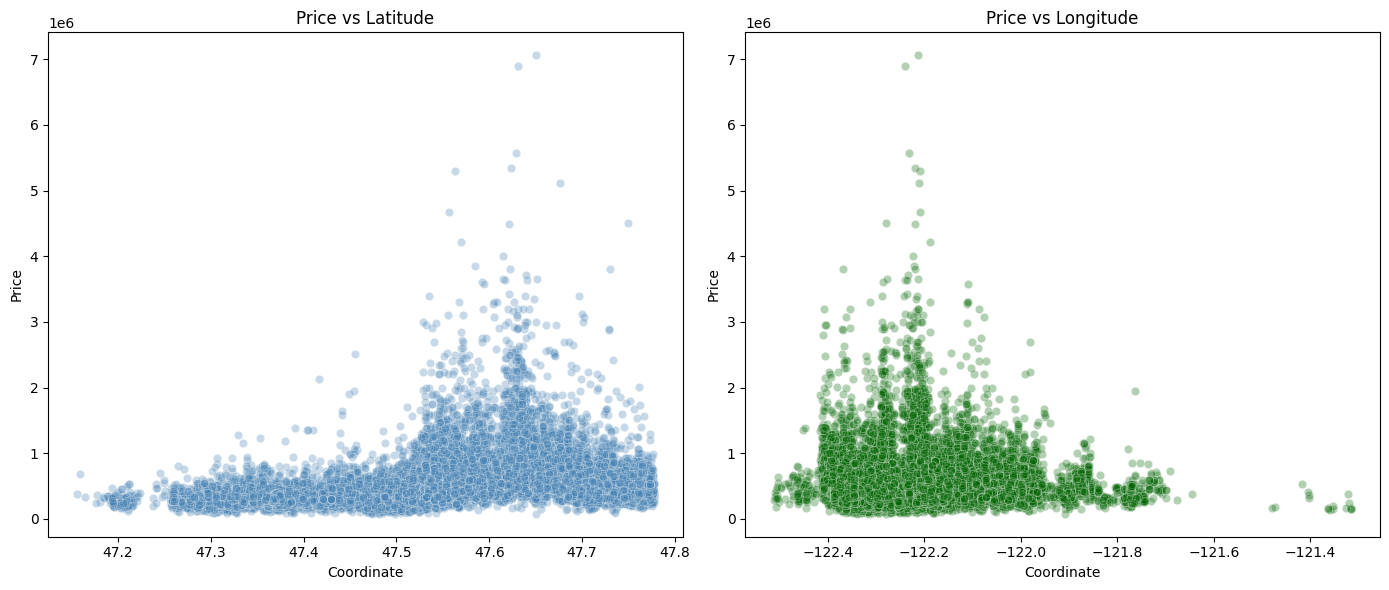

In [73]:
#to be included in the presentation
fig, ax = plt.subplots(1, 2, figsize=(14,6))

sns.scatterplot(
    x=df_import["lat"], y=df_import["price"],
    alpha=0.3, ax=ax[0], color="steelblue"
)
ax[0].set_title("Price vs Latitude")

sns.scatterplot(
    x=df_import["long"], y=df_import["price"],
    alpha=0.3, ax=ax[1], color="darkgreen"
)
ax[1].set_title("Price vs Longitude")

for axis in ax:
    axis.set_ylabel("Price")
    axis.set_xlabel("Coordinate")

plt.tight_layout()
plt.show()
#Prices rise as latitude increases → Northern areas are pricier.
#Longitude pattern shows concentration around –122.35 → central urban areas.
#H2 confirmed.

In [74]:
#Testing Hypothesis: “Renovated homes are more expensive”
#Create a “renovated” flag
df_import["is_renovated"] = df_import["yr_renovated"].apply(lambda x: 1 if x > 0 else 0)

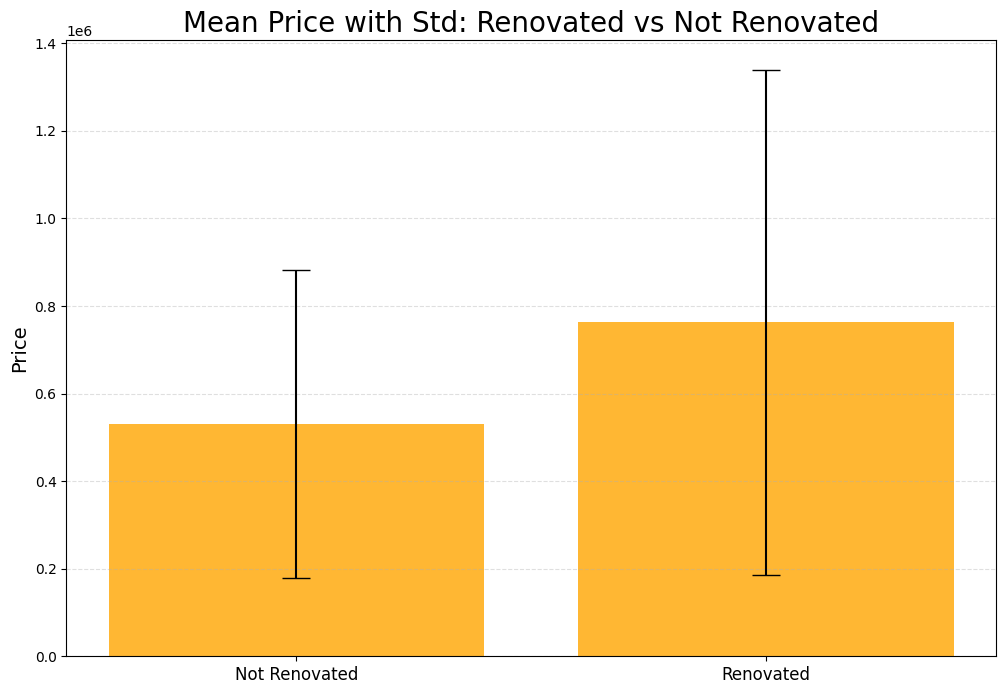

In [ ]:
#to be included in the presentation
#Calculate mean and std price for renovated vs not renovated
mean_prices = df_import.groupby("is_renovated")["price"].mean()
std_prices = df_import.groupby("is_renovated")["price"].std()

# Labels
labels = ["Not Renovated", "Renovated"]

plt.figure(figsize=(12, 8))
x = np.arange(len(labels))

# Plot mean with std whiskers
plt.bar(x, mean_prices, yerr=std_prices, capsize=10, color="orange", alpha=0.8)

# Title & labels
plt.title("Mean Price with Std: Renovated vs Not Renovated", fontsize=20)
plt.ylabel("Price", fontsize=14)
plt.xticks(x, labels, fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.show()

In [ ]:
#to be included in the presentation
mean_price = df_import.groupby("zipcode")["price"].mean()       #zipcodes by mean and min prices
min_price = df_import.groupby("zipcode")["price"].min()

zip_stats = pd.DataFrame({
    "mean_price": mean_price,
    "min_price": min_price
}).sort_values(by="mean_price", ascending=False)

zip_stats.head(10)

,mean_price,min_price
zipcode,,
98039,2161300.000,787500.000
98004,1356523.991,425000.000
98040,1194873.638,500000.000
98112,1096239.007,169317.000
98109,880077.752,216650.000
98105,863228.943,380000.000
98006,859938.554,247500.000
98119,849714.810,300523.000
98102,833584.447,330000.000


In [ ]:
#Client Hypothesis: “Are there affordable central houses for Nicole?”
mid_low, mid_high = df_import["price"].quantile([0.4, 0.6])

In [ ]:
central_area = df_import[                   #Define central region:
    (df_import["lat"].between(47.55, 47.72)) &
    (df_import["long"].between(-122.42, -122.20))
]

In [ ]:
#to be included in the presentation
central_mid = central_area[             #Filter:
    (central_area["price"] >= mid_low) &
    (central_area["price"] <= mid_high)
]

In [ ]:
central_mid.shape[0]            #count

1390

In [ ]:
#to be included in the presentation
#Compute distance of each ZIP code from the center
center_lat = df_import["lat"].mean()
center_long = df_import["long"].mean()

print(center_lat, center_long)
#This is the approximate central geographic point

47.56092215504312 -122.2163065232471


In [ ]:
##to be included in the presentation
#calculate the distance of each home to the central point, then average by ZIP code.
df_import["distance_to_center"] = ((df_import["lat"] - center_lat)**2 + 
                                   (df_import["long"] - center_long)**2)**0.5

zip_distances = df_import.groupby("zipcode")["distance_to_center"].mean().sort_values()
zip_distances.head(10)
#The ZIPs at the top of this list are the most central ZIP codes

zipcode
98040   0.021
98004   0.058
98056   0.062
98118   0.064
98039   0.067
98178   0.070
98006   0.070
98005   0.072
98144   0.086
98007   0.091
Name: distance_to_center, dtype: float64

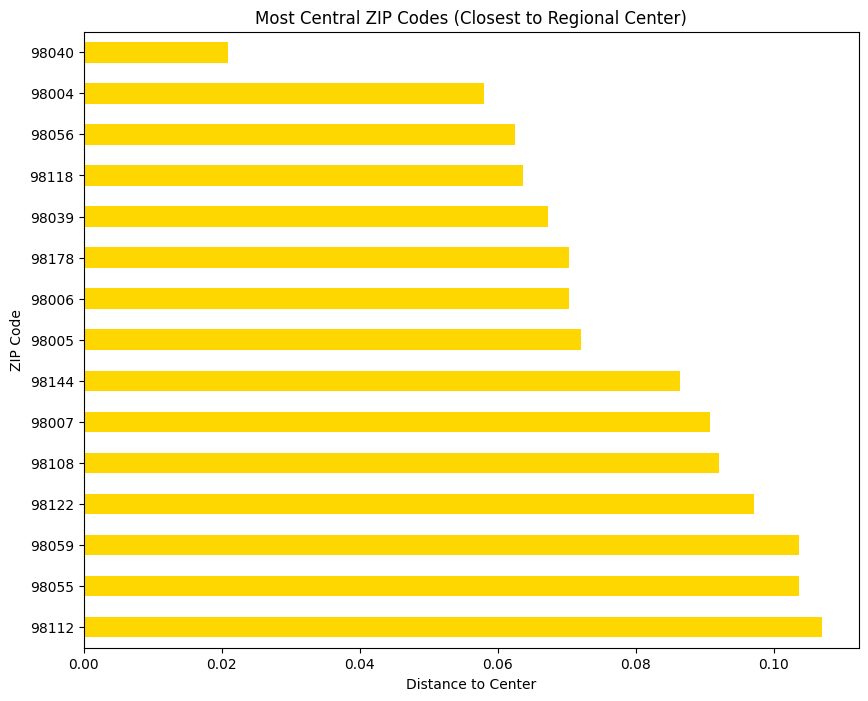

In [83]:
#Visualize the most central ZIP codes
zip_distances.head(15).plot(kind="barh", figsize=(10,8), color="gold")
plt.title("Most Central ZIP Codes (Closest to Regional Center)")
plt.xlabel("Distance to Center")
plt.ylabel("ZIP Code")
plt.gca().invert_yaxis()
plt.show()

In [84]:
#repetition of the code for the calculation of of the best houses in the central parts for Nicole, with fair prices
center_lat = df_import["lat"].mean()
center_long = df_import["long"].mean()

center_lat, center_long

(np.float64(47.56092215504312), np.float64(-122.2163065232471))

In [85]:
df_import["distance_to_center"] = np.sqrt(
    (df_import["lat"] - center_lat)**2 + (df_import["long"] - center_long)**2
)       #CALCULATE DISTANCE TO CENTER FOR EACH HOME

In [86]:
zip_stats = df_import.groupby("zipcode").agg(       #COMBINE ZIPCODE WITH PRICE + CENTRALITY
    mean_price=("price", "mean"),
    median_price=("price", "median"),
    avg_distance=("distance_to_center", "mean"),
    count=("price", "count")
).sort_values("avg_distance")

In [87]:
zip_stats_filtered = zip_stats[zip_stats["count"] > 50]
#REMOVE ZIP CODES WITH LOW SAMPLE SIZE, for instance zip code with just three houses would be noch reliable

In [ ]:
overall_mean = df_import["price"].mean()    #DEFINE “MID-PRICED” (AFFORDABILITY RULE)

In [89]:
best_zipcodes = zip_stats_filtered[
    zip_stats_filtered["mean_price"] <= overall_mean * 1.05
].sort_values("avg_distance").head(10)
#FILTER ZIP CODES THAT ARE BOTH CENTRAL AND MID-PRICED

In [107]:
best_zipcodes

,mean_price,median_price,avg_distance,count
zipcode,,,,
98056,420895.475,380000.000,0.062,406
98118,418019.361,367500.000,0.064,507
98178,310612.756,278277.000,0.070,262
98108,355678.516,342500.000,0.092,186
98059,493308.394,432500.000,0.104,464
98055,304262.108,294950.000,0.104,268
98168,240328.372,235000.000,0.118,269
98188,289078.346,264000.000,0.131,136
98058,347045.244,332500.000,0.135,446


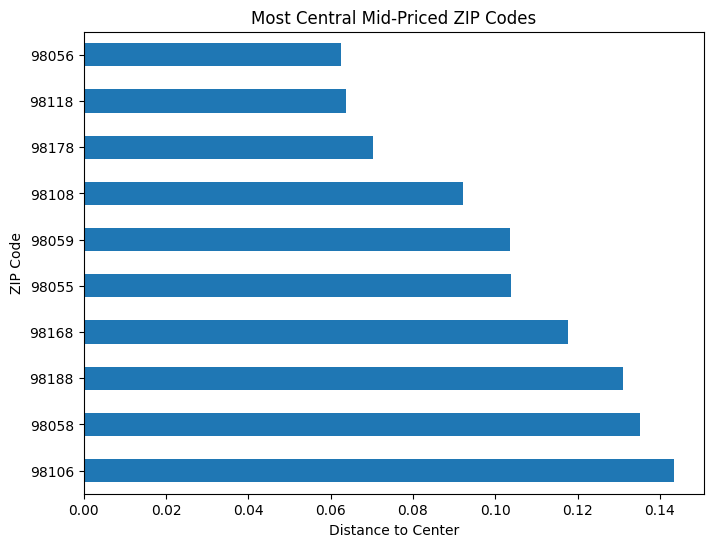

In [91]:
best_zipcodes["avg_distance"].plot(kind="barh", figsize=(8,6))      #Bar chart for centrality:
plt.title("Most Central Mid-Priced ZIP Codes")
plt.xlabel("Distance to Center")
plt.ylabel("ZIP Code")
plt.gca().invert_yaxis()
plt.show()

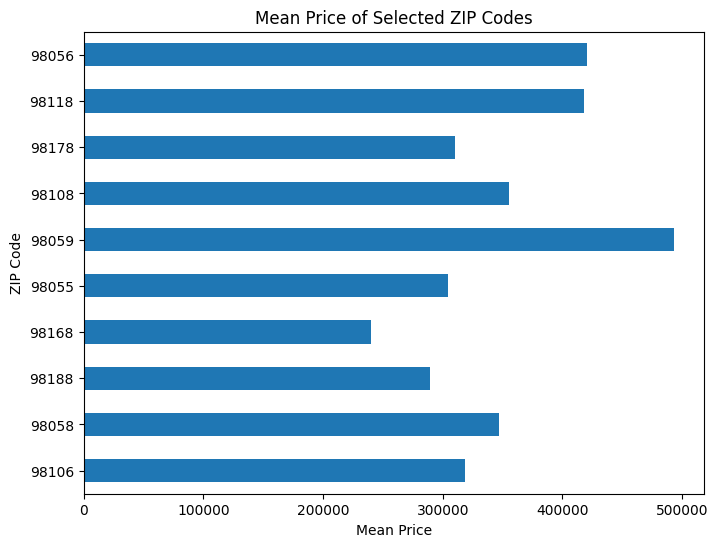

In [92]:
best_zipcodes["mean_price"].plot(kind="barh", figsize=(8,6))        #Bar chart for price:
plt.title("Mean Price of Selected ZIP Codes")
plt.xlabel("Mean Price")
plt.ylabel("ZIP Code")
plt.gca().invert_yaxis()
plt.show()

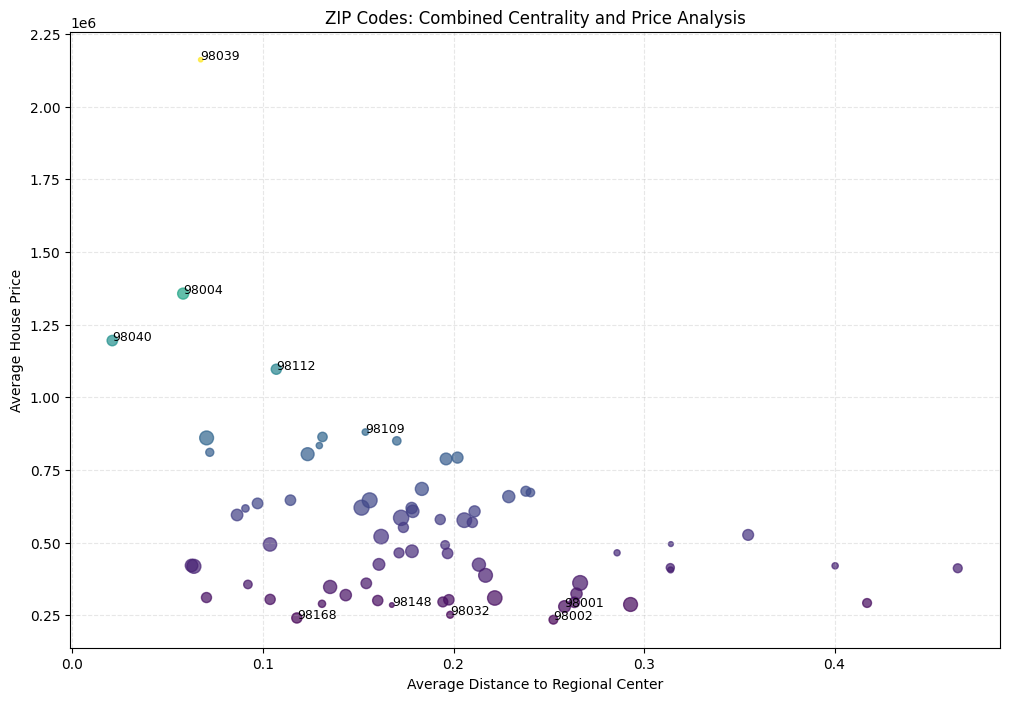

In [ ]:
plt.figure(figsize=(12,8))

plt.scatter(
    zip_stats["avg_distance"], 
    zip_stats["mean_price"],
    s=zip_stats["count"] * 0.2,     # bubble size (more listings = larger bubble)
    alpha=0.7,
    c=zip_stats["mean_price"], 
    cmap="viridis"
)

plt.xlabel("Average Distance to Regional Center")
plt.ylabel("Average House Price")
plt.title("ZIP Codes: Combined Centrality and Price Analysis")

plt.grid(True, linestyle="--", alpha=0.3)

# 5. Label top 5 expensive and top 5 cheap ZIP codes

# Most expensive ZIPs
for zipcode, row in zip_stats.sort_values("mean_price", ascending=False).head(5).iterrows():
    plt.text(row["avg_distance"], row["mean_price"], str(zipcode), fontsize=9)

# Least expensive ZIPs
for zipcode, row in zip_stats.sort_values("mean_price", ascending=True).head(5).iterrows():
    plt.text(row["avg_distance"], row["mean_price"], str(zipcode), fontsize=9)

plt.show()

Hypothesis is not confirmed — Nicole CAN find central homes in the mid-price band.

--Seasonality

In [94]:
# Create time features
df_import["year"] = df_import["date"].dt.year
df_import["month"] = df_import["date"].dt.month
df_import["year_month"] = df_import["date"].dt.to_period("M") 

In [95]:
#how do prices + activity change by month?
monthly = df_import.groupby("year_month").agg(
    median_price=("price", "median"),
    mean_price=("price", "mean"),
    count_sales=("price", "count")
).reset_index()

monthly

#Spring is more expensive than winter.
#But spring has more transactions → more listings, more competition.

,year_month,median_price,mean_price,count_sales
0,2014-05,463500.000,546756.099,1746
1,2014-06,463500.000,556034.683,2158
2,2014-07,464950.000,543598.367,2193
3,2014-08,440000.000,535240.374,1916
4,2014-09,449000.000,529474.486,1750
5,2014-10,445000.000,533472.874,1845
6,2014-11,432000.000,519621.061,1389
7,2014-12,430000.000,523805.897,1451
8,2015-01,435000.000,519760.758,963
9,2015-02,425545.000,507163.334,1234


In [96]:
#Let’s define a central-ish box around Seattle:
central = df_import[
    (df_import["lat"].between(47.55, 47.72)) &
    (df_import["long"].between(-122.42, -122.20))
]

central_monthly = central.groupby("year_month").agg(
    median_price=("price", "median"),
    mean_price=("price", "mean"),
    count_sales=("price", "count")
).reset_index()

central_monthly
#So in Nicole’s target area:
#Spring is slightly more expensive than winter.
#But again more central homes are sold/listed.

,year_month,median_price,mean_price,count_sales
0,2014-05,567500.000,715968.249,538
1,2014-06,575000.000,717444.942,625
2,2014-07,580000.000,706388.559,596
3,2014-08,574000.000,699549.449,512
4,2014-09,555000.000,686721.067,490
5,2014-10,575000.000,711184.149,550
6,2014-11,549975.000,691146.420,410
7,2014-12,575000.000,693940.907,397
8,2015-01,596000.000,715613.306,229
9,2015-02,567500.000,684044.531,322


In [97]:
# Seattle city center
center_lat = 47.6062
center_long = -122.3321

# Euclidean distance (good approximation for small area)
df_import["centrality_score"] = np.sqrt(
    (df_import["lat"] - center_lat)**2 +
    (df_import["long"] - center_long)**2
)
#Seattle center coordinates → (47.6062, -122.3321)

 #Compute ZIP-level average metrics (price + centrality)
zip_stats = df_import.groupby("zipcode").agg(      
    avg_price=("price", "mean"),
    median_price=("price", "median"),
    centrality=("centrality_score", "mean"),
    count=("price", "count")
).sort_values("centrality")

#Create a combined ZIP score (cheapest & most central = best)
zip_stats["price_norm"] = (zip_stats["avg_price"] - zip_stats["avg_price"].min()) / \
                           (zip_stats["avg_price"].max() - zip_stats["avg_price"].min())

zip_stats["centrality_norm"] = (zip_stats["centrality"] - zip_stats["centrality"].min()) / \
                               (zip_stats["centrality"].max() - zip_stats["centrality"].min())

#Lower score = better as final scores
zip_stats["combined_score"] = (
    zip_stats["price_norm"] * 0.5 +
    zip_stats["centrality_norm"] * 0.5
)

best_zips = zip_stats.sort_values("combined_score").head(3)
best_zips

,avg_price,median_price,centrality,count,price_norm,centrality_norm,combined_score
zipcode,,,,,,,
98108,355678.516,342500.000,0.063,186,0.063,0.056,0.059
98106,318981.338,314250.000,0.075,334,0.044,0.078,0.061
98168,240328.372,235000.000,0.120,269,0.003,0.159,0.081


In [98]:
import folium

m = folium.Map(location=[47.6062, -122.3321], zoom_start=10)

for z in best_zips.index:
    subset = df_import[df_import["zipcode"] == z]
    lat_mean = subset["lat"].mean()
    long_mean = subset["long"].mean()

    folium.CircleMarker(
        location=[lat_mean, long_mean],
        radius=8,
        popup=f"ZIP {z}",
        color="red",
        fill=True,
        fill_color="red"
    ).add_to(m)

m

In [99]:
m.save("best_zipcodes_map.html")        #saves the map as an html file in the folder

In [100]:
best_zips = [98108, 98106, 98168]

df_best_area = df_import[df_import["zipcode"].isin(best_zips)].copy()

# Realistic mid-range buyer filters
df_best_area = df_best_area[
    (df_best_area["price"] >= 350000) &
    (df_best_area["price"] <= 650000) &
    (df_best_area["sqft_living"] >= 1000) &
    (df_best_area["bedrooms"] >= 2) &
    (df_best_area["bathrooms"] >= 1) &
    (df_best_area["condition"] >= 3)
]

# Price per sqft
df_best_area["price_per_sqft"] = df_best_area["price"] / df_best_area["sqft_living"]

# New improved scoring
df_best_area["score"] = (
    -0.3 * df_best_area["price_per_sqft"] +
    -0.4 * df_best_area["price"] +
    0.3 * df_best_area["sqft_living"]
)

# Pick top 3 houses
top3 = df_best_area.sort_values("score", ascending=False).head(3)
top3

,date,price,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_lot15_log,is_renovated,decade_built,distance_to_center,year,month,year_month,centrality_score,price_per_sqft,score
13781,2015-04-02,350000.000,797000258,2.000,2.750,2820.000,11770.000,2.000,0,0.000,...,9.434,0,1940,0.119,2015,4,2015-04,0.096,124.113,-139191.234
15342,2014-08-21,350000.000,6433000050,4.000,1.750,2740.000,10086.000,1.000,0,0.000,...,9.194,0,1970,0.123,2014,8,2014-08,0.095,127.737,-139216.321
17638,2015-05-05,350000.000,1773100620,5.000,3.000,2320.000,8400.000,1.000,0,0.000,...,8.477,0,1960,0.149,2015,5,2015-05,0.059,150.862,-139349.259


In [108]:
top3[["price", "sqft_living", "bedrooms", "bathrooms", "zipcode", "price_per_sqft", "score"]]

,price,sqft_living,bedrooms,bathrooms,zipcode,price_per_sqft,score
13781,350000.000,2820.000,2.000,2.750,98168,124.113,-139191.234
15342,350000.000,2740.000,4.000,1.750,98168,127.737,-139216.321
17638,350000.000,2320.000,5.000,3.000,98106,150.862,-139349.259


In [109]:
# Selected houses
selected_indices = [13781, 15342, 17638]
df_sel = df_import.loc[selected_indices]

# Create map centered on Seattle
m = folium.Map(location=[47.6062, -122.3321], zoom_start=11)

# Add markers for the 3 recommended houses
for i, row in df_sel.iterrows():
    folium.Marker(
        location=[row["lat"], row["long"]],
        popup=(
            f"<b>House ID:</b> {row['id']}<br>"
            f"<b>ZIP:</b> {row['zipcode']}<br>"
            f"<b>Price:</b> ${row['price']:,.0f}<br>"
            f"<b>Sqft living:</b> {row['sqft_living']}<br>"
            f"<b>Bedrooms:</b> {row['bedrooms']}<br>"
            f"<b>Bathrooms:</b> {row['bathrooms']}"
        ),
        icon=folium.Icon(color="red", icon="home")
    ).add_to(m)

# Save map to current working directory
m.save("selected_houses_map.html")

"Map saved as selected_houses_map.html"
      

'Map saved as selected_houses_map.html'

In [110]:
#saves the map as an html file in the folder

If Nicole wants to save money, then:
 Late autumn to late winter → November to February

Slightly lower median prices
Less competition
But fewer listings (she must be patient)

If Nicole’s wants to prioritize lively neighborhood, then:
 Early spring, especially March

Big jump in number of available houses
Prices are rising but not yet at the very top
Good balance between choice and cost





